# GNN + latent field: набор экспериментов

Этот ноутбук нужен для быстрых локальных сравнений:

- обычный one-step GNN baseline;
- sequence GNN + spatial latent field с `bptt_window=3`;
- ablation `bptt_window=1`, чтобы проверить, дает ли поле именно память, а не просто дополнительный read context;
- чтение готовых `history.csv` / `run_summary.json` и построение графиков.

По умолчанию ноутбук **ничего тяжелого не запускает**. Он анализирует уже существующие run-директории. Чтобы запустить обучение из ноутбука, в конфиге ниже поставь `RUN_EXPERIMENTS = True`.


In [23]:
from __future__ import annotations

import json
# import os
import shlex
import subprocess
import sys
from pathlib import Path
from typing import Any

import matplotlib.pyplot as plt
import pandas as pd

plt.style.use("seaborn-v0_8-whitegrid")
pd.set_option("display.max_columns", 120)
pd.set_option("display.width", 160)

# Notebook is expected to live in Real_game_of_life/GNN.
NOTEBOOK_DIR = Path.cwd()
if NOTEBOOK_DIR.name == "GNN":
    REPO_ROOT = NOTEBOOK_DIR.parents[1]
elif (NOTEBOOK_DIR / "Real_game_of_life" / "GNN").exists():
    REPO_ROOT = NOTEBOOK_DIR
else:
    # Fallback for running after opening the notebook from another working directory.
    REPO_ROOT = Path("/mnt/d/Proga/Game_of_life")

PROJECT = REPO_ROOT / "Real_game_of_life"
GNN_DIR = PROJECT / "GNN"
RUNS_DIR = GNN_DIR / "runs"
CACHE_DIR = GNN_DIR / "cache"

# Use the current notebook kernel by default. If needed, set this to the local Anaconda path explicitly.
PYTHON_EXE = sys.executable
# PYTHON_EXE = "/mnt/d/Anaconda3/NewAnaconda/python.exe"

print("REPO_ROOT:", REPO_ROOT)
print("PYTHON_EXE:", PYTHON_EXE)
print("RUNS_DIR:", RUNS_DIR)


REPO_ROOT: d:\Proga\Game_of_life
PYTHON_EXE: d:\Anaconda3\NewAnaconda\python.exe
RUNS_DIR: d:\Proga\Game_of_life\Real_game_of_life\GNN\runs


## Конфигурация

`CACHE_PATH` можно поменять на другой cache. Для честного сравнения baseline и field лучше использовать один и тот же cache и один и тот же split. Сейчас основной кандидат - balanced cache на 500 графов.


In [ ]:
CACHE_MAX_GRAPHS = None  # Increase this to 5000 or set to None for the full available dataset.
CACHE_TAG = "full" if CACHE_MAX_GRAPHS is None else str(CACHE_MAX_GRAPHS)
CACHE_PATH = CACHE_DIR / f"frame_graphs_dynamic_v2_{CACHE_TAG}_balanced.pt"
RUN_TAG = f"{CACHE_TAG}_balanced"

RUN_EXPERIMENTS = True  # Set True only after the larger cache exists and you are ready to run training.
CREATE_CACHE_IF_MISSING = True  # Build CACHE_PATH automatically when it does not exist.
DEVICE = "cpu"
EPOCHS = 30
HIDDEN_DIM = 32
LAYERS = 2
DROPOUT = 0.1

FIELD_CHANNELS = 8
FIELD_CONTEXT_DIM = 16
FIELD_UPDATE_HIDDEN_CHANNELS = 16
# Keep 128x128 for the larger-data experiment. Auto geometry maps the ~0..510 physical coordinates into this field.
FIELD_HEIGHT = 128
FIELD_WIDTH = 128


def run_dir(name: str) -> Path:
    return RUNS_DIR / f"{name}_local_{RUN_TAG}"


def one_step_args(name: str, model_type: str = "gnn") -> list[str]:
    return [
        "-m", "Real_game_of_life.GNN.train_one_step",
        "--cache", str(CACHE_PATH),
        "--out-dir", str(run_dir(name)),
        "--model-type", model_type,
        "--epochs", str(EPOCHS),
        "--hidden-dim", str(HIDDEN_DIM),
        "--layers", str(LAYERS),
        "--dropout", str(DROPOUT),
        "--batch-size", "16",
        "--device", DEVICE,
    ]


def field_sequence_args(name: str, bptt_window: int) -> list[str]:
    return [
        "-m", "Real_game_of_life.GNN.train_field_sequence",
        "--cache", str(CACHE_PATH),
        "--out-dir", str(run_dir(name)),
        "--epochs", str(EPOCHS),
        "--hidden-dim", str(HIDDEN_DIM),
        "--layers", str(LAYERS),
        "--dropout", str(DROPOUT),
        "--field-channels", str(FIELD_CHANNELS),
        "--field-height", str(FIELD_HEIGHT),
        "--field-width", str(FIELD_WIDTH),
        "--field-context-dim", str(FIELD_CONTEXT_DIM),
        "--field-update-hidden-channels", str(FIELD_UPDATE_HIDDEN_CHANNELS),
        "--bptt-window", str(bptt_window),
        "--device", DEVICE,
    ]


EXPERIMENTS = {
    "gnn_baseline": {
        "kind": "one_step",
        "out_dir": run_dir("gnn_baseline"),
        "args": one_step_args("gnn_baseline"),
    },
    "field_bptt1": {
        "kind": "field_sequence",
        "out_dir": run_dir("field_sequence_bptt1"),
        "args": field_sequence_args("field_sequence_bptt1", 1),
    },
    "field_bptt3": {
        "kind": "field_sequence",
        "out_dir": run_dir("field_sequence_bptt3"),
        "args": field_sequence_args("field_sequence_bptt3", 3),
    },
    "field_bptt15": {
        "kind": "field_sequence",
        "out_dir": run_dir("field_sequence_bptt15"),
        "args": field_sequence_args("field_sequence_bptt15", 15),
    },
}

pd.DataFrame([
    {"experiment": name, "kind": cfg["kind"], "out_dir": str(cfg["out_dir"])}
    for name, cfg in EXPERIMENTS.items()
])

,experiment,kind,out_dir
0,gnn_baseline,one_step,d:\Proga\Game_of_life\Real_game_of_life\GNN\ru...
1,field_bptt1,field_sequence,d:\Proga\Game_of_life\Real_game_of_life\GNN\ru...
2,field_bptt3,field_sequence,d:\Proga\Game_of_life\Real_game_of_life\GNN\ru...
3,field_bptt15,field_sequence,d:\Proga\Game_of_life\Real_game_of_life\GNN\ru...


## Проверка cache

Field-модели требуют cache v2 с `data.pos_xy`. Если файла нет, сначала собери cache командой ниже. Ячейка только печатает команду, чтобы случайно не запустить долгую подготовку данных.


In [25]:
def format_command(args: list[str]) -> str:
    return " ".join(shlex.quote(str(x)) for x in args)

cache_build_command = [
    PYTHON_EXE,
    "-m", "Real_game_of_life.GNN.dataset_cache",
    "--out", str(CACHE_PATH),
    "--split-mode", "by_position_event_balanced",
]
if CACHE_MAX_GRAPHS is not None:
    cache_build_command.extend(["--max-graphs", str(CACHE_MAX_GRAPHS)])

print("Cache exists:", CACHE_PATH.exists(), CACHE_PATH)
print("Cache max graphs:", CACHE_MAX_GRAPHS)
print("Build command:")
print(format_command(cache_build_command))

if not CACHE_PATH.exists():
    if CREATE_CACHE_IF_MISSING:
        print("\nCache is missing. Building it now...")
        CACHE_PATH.parent.mkdir(parents=True, exist_ok=True)
        completed = subprocess.run(cache_build_command, cwd=str(REPO_ROOT), text=True)
        if completed.returncode != 0:
            raise RuntimeError(f"Cache build failed with exit code {completed.returncode}")
        print("Cache created:", CACHE_PATH)
    else:
        print("\nCache is missing. Set CREATE_CACHE_IF_MISSING=True to build it automatically.")
else:
    print("\nUsing existing cache:", CACHE_PATH)

Cache exists: True d:\Proga\Game_of_life\Real_game_of_life\GNN\cache\frame_graphs_dynamic_v2_full_balanced.pt
Cache max graphs: None
Build command:
'd:\Anaconda3\NewAnaconda\python.exe' -m Real_game_of_life.GNN.dataset_cache --out 'd:\Proga\Game_of_life\Real_game_of_life\GNN\cache\frame_graphs_dynamic_v2_full_balanced.pt' --split-mode by_position_event_balanced

Using existing cache: d:\Proga\Game_of_life\Real_game_of_life\GNN\cache\frame_graphs_dynamic_v2_full_balanced.pt


## Запуск экспериментов

Эта ячейка запускает обучение только если `RUN_EXPERIMENTS = True`. Для увеличенного набора сначала собери cache из предыдущей ячейки. На CPU начни с `CACHE_MAX_GRAPHS = 2000`; полный dataset лучше запускать на CUDA или отдельно на ночь.

In [26]:
def run_command(args: list[str], cwd: Path = REPO_ROOT) -> None:
    print("\n$", format_command(args))
    completed = subprocess.run(args, cwd=str(cwd), text=True)
    if completed.returncode != 0:
        raise RuntimeError(f"Command failed with exit code {completed.returncode}")

if RUN_EXPERIMENTS:
    for name, cfg in EXPERIMENTS.items():
        print(f"\n=== {name} ===")
        run_command([PYTHON_EXE, *cfg["args"]])
else:
    print("RUN_EXPERIMENTS=False: обучение не запускается, читаем существующие результаты.")



=== gnn_baseline ===

$ 'd:\Anaconda3\NewAnaconda\python.exe' -m Real_game_of_life.GNN.train_one_step --cache 'd:\Proga\Game_of_life\Real_game_of_life\GNN\cache\frame_graphs_dynamic_v2_full_balanced.pt' --out-dir 'd:\Proga\Game_of_life\Real_game_of_life\GNN\runs\gnn_baseline_local_full_balanced' --model-type gnn --epochs 30 --hidden-dim 32 --layers 2 --dropout 0.1 --batch-size 16 --device cpu

=== field_bptt1 ===

$ 'd:\Anaconda3\NewAnaconda\python.exe' -m Real_game_of_life.GNN.train_field_sequence --cache 'd:\Proga\Game_of_life\Real_game_of_life\GNN\cache\frame_graphs_dynamic_v2_full_balanced.pt' --out-dir 'd:\Proga\Game_of_life\Real_game_of_life\GNN\runs\field_sequence_bptt1_local_full_balanced' --epochs 30 --hidden-dim 32 --layers 2 --dropout 0.1 --field-channels 8 --field-height 128 --field-width 128 --field-context-dim 16 --field-update-hidden-channels 16 --bptt-window 1 --device cpu

=== field_bptt3 ===

$ 'd:\Anaconda3\NewAnaconda\python.exe' -m Real_game_of_life.GNN.train_fiel

## Загрузка результатов

Если какой-то run еще не существует, он будет пропущен. После запуска новых экспериментов просто перезапусти эту ячейку и графики ниже.


In [27]:
def read_json(path: Path) -> dict[str, Any]:
    return json.loads(path.read_text(encoding="utf-8"))

def load_experiment(name: str, out_dir: Path) -> tuple[pd.DataFrame | None, dict[str, Any] | None]:
    history_path = out_dir / "history.csv"
    summary_path = out_dir / "run_summary.json"
    history = None
    summary = None
    if history_path.exists():
        history = pd.read_csv(history_path)
        history.insert(0, "experiment", name)
    if summary_path.exists():
        summary = read_json(summary_path)
        summary["experiment"] = name
        summary["out_dir"] = str(out_dir)
    return history, summary

histories = []
summaries = []
missing = []
for name, cfg in EXPERIMENTS.items():
    history, summary = load_experiment(name, cfg["out_dir"])
    if history is None or summary is None:
        missing.append(name)
        continue
    histories.append(history)
    summaries.append(summary)

history_df = pd.concat(histories, ignore_index=True, sort=False) if histories else pd.DataFrame()
summary_df = pd.DataFrame([
    {
        "experiment": s["experiment"],
        "model_type": s.get("model_type"),
        "best_epoch": s.get("best_epoch"),
        "best_metric": s.get("best_metric"),
        "epochs_completed": s.get("epochs_completed"),
        "train_graphs": s.get("train_graphs"),
        "val_graphs": s.get("val_graphs"),
        "test_graphs": s.get("test_graphs"),
        "out_dir": s.get("out_dir"),
    }
    for s in summaries
])

print("Loaded experiments:", [s["experiment"] for s in summaries])
print("Missing/incomplete:", missing)
summary_df


Loaded experiments: ['gnn_baseline', 'field_bptt1', 'field_bptt3', 'field_bptt15']
Missing/incomplete: []


,experiment,model_type,best_epoch,best_metric,epochs_completed,train_graphs,val_graphs,test_graphs,out_dir
0,gnn_baseline,gnn,2,2.503481,30,1680,336,378,d:\Proga\Game_of_life\Real_game_of_life\GNN\ru...
1,field_bptt1,field_sequence,4,3.518961,30,1680,336,378,d:\Proga\Game_of_life\Real_game_of_life\GNN\ru...
2,field_bptt3,field_sequence,1,3.620104,30,1680,336,378,d:\Proga\Game_of_life\Real_game_of_life\GNN\ru...
3,field_bptt15,field_sequence,1,3.026207,30,1680,336,378,d:\Proga\Game_of_life\Real_game_of_life\GNN\ru...


## Split и редкие события

Перед сравнением метрик важно смотреть, есть ли positive events в val/test. Если в split нет делений, `division_ap` на нем почти неинформативен.


In [28]:
def split_target_table(summary: dict[str, Any]) -> pd.DataFrame:
    counts = summary.get("cache_summary", {}).get("split_target_counts", {})
    rows = []
    for split, targets in counts.items():
        for target, data in targets.items():
            rows.append({
                "experiment": summary["experiment"],
                "split": split,
                "target": target,
                "valid": data.get("valid"),
                "positives": data.get("positives"),
                "positive_rate": (data.get("positives", 0) / data.get("valid", 1)) if data.get("valid") else 0.0,
            })
    return pd.DataFrame(rows)

split_targets_df = pd.concat([split_target_table(s) for s in summaries], ignore_index=True) if summaries else pd.DataFrame()
if not split_targets_df.empty:
    display(split_targets_df.pivot_table(index=["split", "target"], columns="experiment", values="positives", aggfunc="first"))
else:
    print("Нет загруженных summary.")


experiment           field_bptt1  field_bptt15  field_bptt3  gnn_baseline
split target                                                             
test  disappearance          188           188          188           188
      division                14            14           14            14
      division_h10            74            74           74            74
      division_h3             33            33           33            33
      division_h5             48            48           48            48
train disappearance          862           862          862           862
      division                25            25           25            25
      division_h10           132           132          132           132
      division_h3             62            62           62            62
      division_h5             89            89           89            89
val   disappearance          233           233          233           233
      division                12            12           12            12
      division_h10            60            60           60            60
      division_h3             31            31           31            31
      division_h5             42            42           42            42

## Кривые обучения

Смотрим train/val loss и `pos_rmse`. Для sequence field метрики считаются по последовательностям, для baseline - по one-step батчам, поэтому throughput сравнивать осторожно.


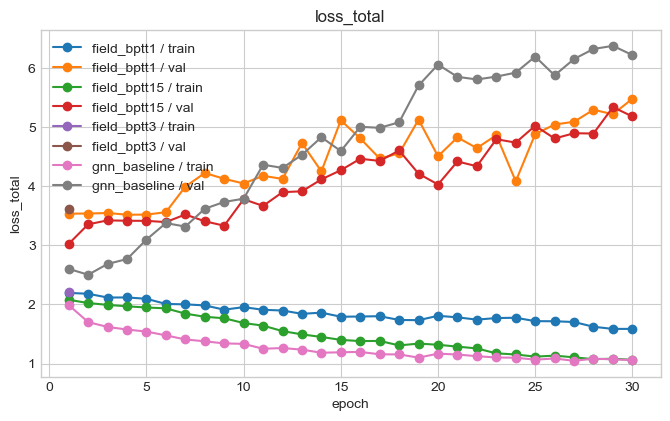

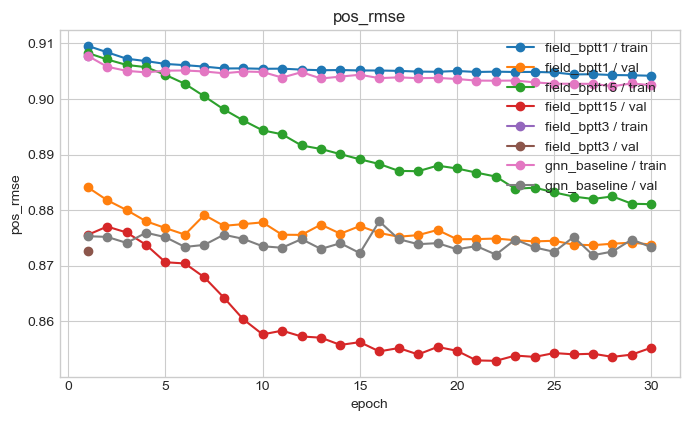

In [29]:
def plot_history_metric(metric: str, phases=("train", "val")) -> None:
    if history_df.empty or metric not in history_df.columns:
        print(f"Нет колонки {metric!r}")
        return
    data = history_df[history_df["phase"].isin(phases)].copy()
    if data.empty:
        print("Нет данных для выбранных phase.")
        return
    fig, ax = plt.subplots(figsize=(8, 4.5))
    for (experiment, phase), group in data.groupby(["experiment", "phase"]):
        group = group.sort_values("epoch")
        ax.plot(group["epoch"], group[metric], marker="o", label=f"{experiment} / {phase}")
    ax.set_title(metric)
    ax.set_xlabel("epoch")
    ax.set_ylabel(metric)
    ax.legend(loc="best")
    plt.show()

plot_history_metric("loss_total")
plot_history_metric("pos_rmse")


## Сравнение test metrics

Ниже собраны основные метрики из `run_summary.json -> test_metrics`. Для loss/RMSE меньше лучше, для AP/top-k больше лучше.


In [30]:
def test_metrics_table(summaries: list[dict[str, Any]]) -> pd.DataFrame:
    rows = []
    for summary in summaries:
        metrics = summary.get("test_metrics") or {}
        row = {"experiment": summary["experiment"]}
        row.update(metrics)
        rows.append(row)
    return pd.DataFrame(rows)

test_df = test_metrics_table(summaries)
core_metrics = [
    "loss_total",
    "pos_rmse",
    "shape_rmse",
    "death_ap",
    "division_ap",
    "division_h3_ap",
    "division_h5_ap",
    "division_h10_ap",
]
existing_core = [m for m in core_metrics if m in test_df.columns]
if not test_df.empty:
    display(test_df[["experiment", *existing_core]].sort_values("experiment"))
else:
    print("Нет test metrics. Возможно, cache был без val/test split.")


,experiment,loss_total,pos_rmse,shape_rmse,death_ap,division_ap,division_h3_ap,division_h5_ap,division_h10_ap
1,field_bptt1,4.506814,0.922967,0.067306,0.149930,0.001260,0.005138,0.007607,0.012687
3,field_bptt15,3.704523,0.921655,0.078521,0.195385,0.001331,0.025950,0.039378,0.064881
2,field_bptt3,4.403550,0.918375,0.068995,0.144466,0.003350,0.046092,0.039659,0.049008
0,gnn_baseline,3.109248,0.919146,0.075119,0.157148,0.004328,0.163226,0.189039,0.151571


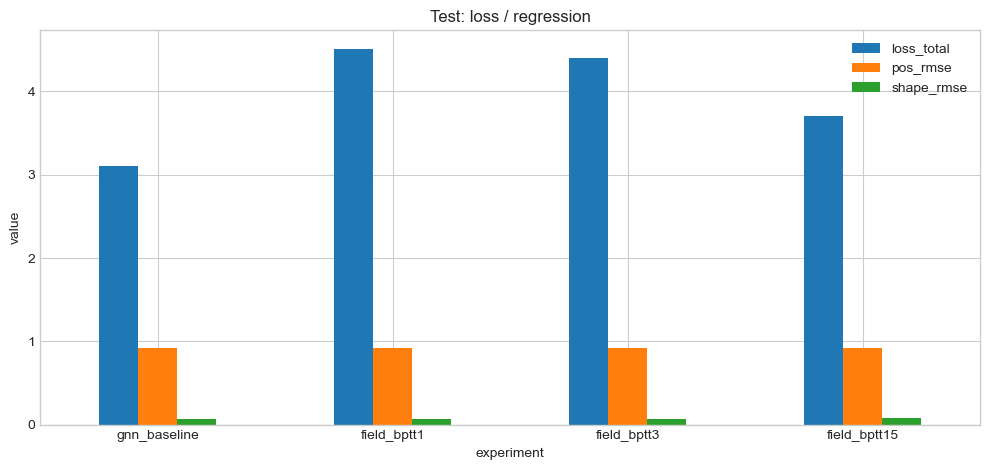

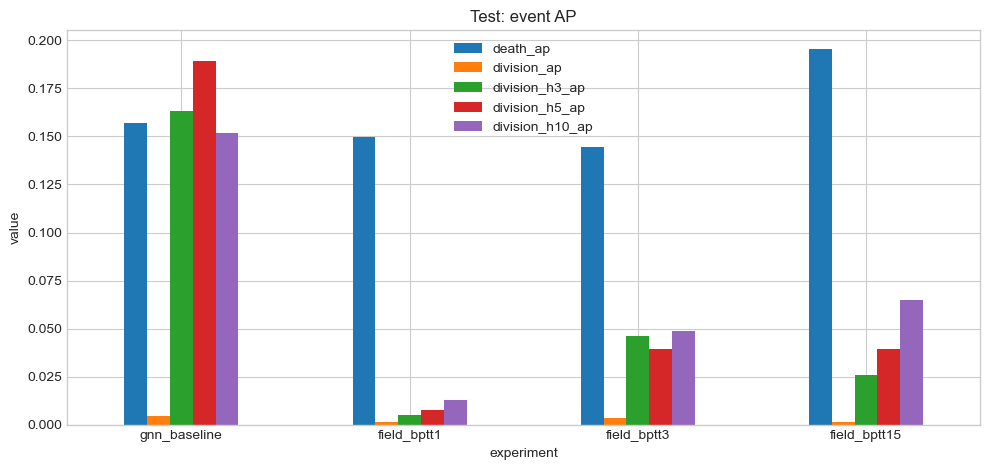

In [31]:
def bar_metrics(df: pd.DataFrame, metrics: list[str], title: str) -> None:
    metrics = [m for m in metrics if m in df.columns]
    if df.empty or not metrics:
        print("Нет данных для графика:", title)
        return
    plot_df = df.set_index("experiment")[metrics]
    ax = plot_df.plot(kind="bar", figsize=(10, 4.8), rot=0)
    ax.set_title(title)
    ax.set_ylabel("value")
    ax.legend(loc="best")
    plt.tight_layout()
    plt.show()

bar_metrics(test_df, ["loss_total", "pos_rmse", "shape_rmse"], "Test: loss / regression")
bar_metrics(test_df, ["death_ap", "division_ap", "division_h3_ap", "division_h5_ap", "division_h10_ap"], "Test: event AP")


## Top-k для division horizon

Для редких делений top-k часто полезнее accuracy: показывает, попадают ли реальные события в верх ранжирования модели.


,experiment,division_top10_hits,division_top50_hits,division_top100_hits,division_h3_top50_hits,division_h5_top50_hits,division_h10_top50_hits,division_h3_top100_hits,division_h5_top100_hits,division_h10_top100_hits
1,field_bptt1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,field_bptt15,0.0,0.0,0.0,2.0,6.0,7.0,6.0,9.0,10.0
2,field_bptt3,0.0,0.0,0.0,3.0,2.0,4.0,4.0,4.0,5.0
0,gnn_baseline,0.0,0.0,0.0,7.0,10.0,13.0,9.0,12.0,16.0


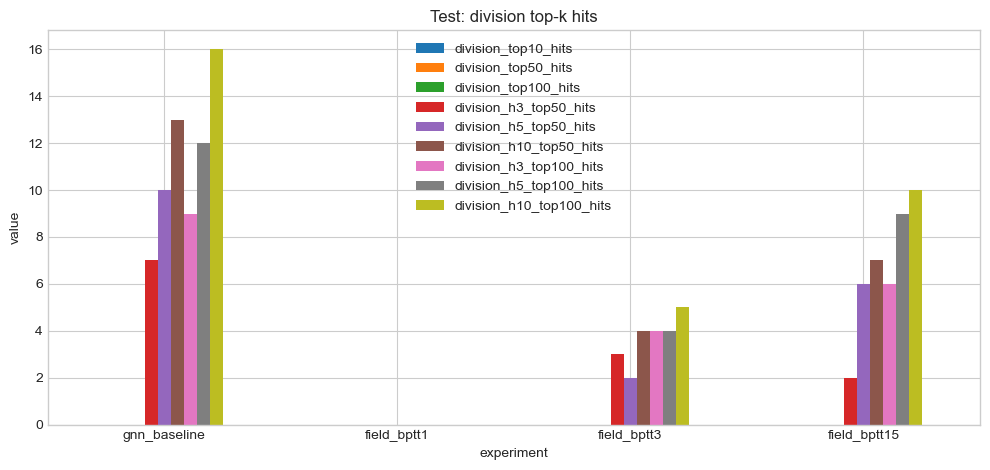

In [32]:
topk_metrics = [
    "division_top10_hits", "division_top50_hits", "division_top100_hits",
    "division_h3_top50_hits", "division_h5_top50_hits", "division_h10_top50_hits",
    "division_h3_top100_hits", "division_h5_top100_hits", "division_h10_top100_hits",
]
existing_topk = [m for m in topk_metrics if m in test_df.columns]
if not test_df.empty and existing_topk:
    display(test_df[["experiment", *existing_topk]].sort_values("experiment"))
    bar_metrics(test_df, existing_topk, "Test: division top-k hits")
else:
    print("Нет top-k metrics.")


## Автоматический короткий вывод

Это не заменяет анализ, но помогает быстро увидеть, где field выигрывает или проигрывает baseline на текущем split.


In [33]:
def lower_is_better(metric: str) -> bool:
    return metric.startswith("loss") or metric.endswith("rmse") or metric.endswith("seconds")

def compare_against_baseline(df: pd.DataFrame, baseline: str = "gnn_baseline") -> pd.DataFrame:
    if df.empty or baseline not in set(df["experiment"]):
        return pd.DataFrame()
    base = df[df["experiment"] == baseline].iloc[0]
    rows = []
    for _, row in df[df["experiment"] != baseline].iterrows():
        for metric in existing_core:
            b = base.get(metric)
            v = row.get(metric)
            if pd.isna(b) or pd.isna(v):
                continue
            delta = v - b
            better = delta < 0 if lower_is_better(metric) else delta > 0
            rows.append({
                "experiment": row["experiment"],
                "metric": metric,
                "baseline": b,
                "value": v,
                "delta": delta,
                "better_than_baseline": better,
            })
    return pd.DataFrame(rows)

comparison_df = compare_against_baseline(test_df)
if not comparison_df.empty:
    display(comparison_df)
else:
    print("Нет baseline или test metrics для сравнения.")


,experiment,metric,baseline,value,delta,better_than_baseline
0,field_bptt1,loss_total,3.109248,4.506814,1.397566,False
1,field_bptt1,pos_rmse,0.919146,0.922967,0.003821,False
2,field_bptt1,shape_rmse,0.075119,0.067306,-0.007812,True
3,field_bptt1,death_ap,0.157148,0.149930,-0.007219,False
4,field_bptt1,division_ap,0.004328,0.001260,-0.003068,False
5,field_bptt1,division_h3_ap,0.163226,0.005138,-0.158088,False
6,field_bptt1,division_h5_ap,0.189039,0.007607,-0.181432,False
7,field_bptt1,division_h10_ap,0.151571,0.012687,-0.138884,False
8,field_bptt3,loss_total,3.109248,4.403550,1.294303,False
9,field_bptt3,pos_rmse,0.919146,0.918375,-0.000771,True


## Интерпретация для текущей гипотезы

Минимальная проверка гипотезы про память поля:

1. `field_bptt3` должен быть лучше `field_bptt1` на horizon-событиях (`division_h5`, `division_h10`) или top-k.
2. Если `field_bptt3` примерно равен `field_bptt1`, поле пока работает как дополнительный spatial read context, а не как полезная recurrent memory.
3. Если оба field-варианта проигрывают GNN baseline по loss и event AP, надо сначала проверить calibration/loss weights, а не усложнять архитектуру.
4. Accuracy для division почти бесполезна из-за редкости события; смотреть `AP`, `recall`, `top-k hits` и число positives в split.
